## Step 1 — Data Preparation

In this stage we clean and prepare the dataset for analysis.

Tasks performed:
- Inspect dataset structure
- Check missing values
- Remove duplicates
- Standardize column names
- Create time-based features

In [1]:
import pandas as pd

# load dataset
df = pd.read_excel("../data/raw/sample_-_superstore.xls")

# preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [2]:
df.shape

(10194, 21)

In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  str           
 6   Customer Name   10194 non-null  str           
 7   Segment         10194 non-null  str           
 8   Country/Region  10194 non-null  str           
 9   City            10194 non-null  str           
 10  State/Province  10194 non-null  str           
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  str           
 13  Product ID      10194 non-null  str           
 14  Category        10194 non-null  str           
 15  Sub-Category 

In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country/region', 'city',
       'state/province', 'postal_code', 'region', 'product_id', 'category',
       'sub_category', 'product_name', 'sales', 'quantity', 'discount',
       'profit'],
      dtype='str')

In [8]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

In [9]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["profit_margin"] = df["profit"] / df["sales"]

In [10]:
df.to_csv("../Data/cleaned/sales_cleaned.csv", index=False)

## Step 2 — Business Analysis

After preparing the dataset, we analyze key business metrics to understand sales performance across regions, categories, and time.

In [11]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2326534.3543
Total Profit: 292296.8145999999
Total Orders: 5111


In [12]:
sales_by_region = df.groupby("region")["sales"].sum().sort_values(ascending=False)
sales_by_region

region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: sales, dtype: float64

In [13]:
sales_by_category = df.groupby("category")["sales"].sum().sort_values(ascending=False)
sales_by_category

category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: sales, dtype: float64

In [14]:
profit_by_category = df.groupby("category")["profit"].sum().sort_values(ascending=False)
profit_by_category

category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: profit, dtype: float64

In [15]:
top_products = (
    df.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

In [16]:
monthly_sales = df.groupby(["year","month"])["sales"].sum()
monthly_sales

year  month
2023  1         14518.0550
      2          4519.8920
      3         56933.9090
      4         28295.3450
      5         26319.7670
      6         34669.4796
      7         33946.3930
      8         28918.3385
      9         82670.4288
      10        32413.3390
      11        78826.9567
      12        72008.3085
2024  1         18461.9156
      2         11951.4110
      3         39978.6280
      4         34195.2085
      5         30246.9465
      6         24797.2920
      7         28765.3250
      8         37057.0042
      9         64627.0460
      10        31407.1335
      11        75972.5635
      12        75532.5572
2025  1         18830.3310
      2         22978.8150
      3         53031.0690
      4         38829.1590
      5         57042.8380
      6         40937.1480
      7         40300.4990
      8         31716.8143
      9         73521.6629
      10        59831.0010
      11        79411.9658
      12        97502.2770
2026  1         

## Step 3 — Visual Exploration

Visualizations are created to better understand patterns in sales data including regional performance, product categories, top products, and monthly sales trends.

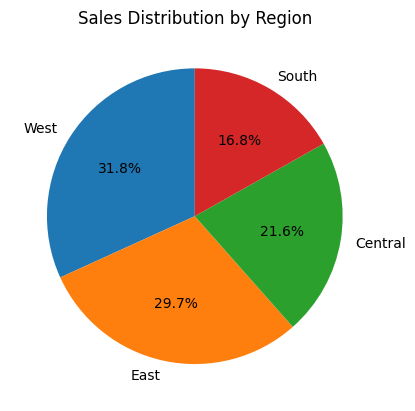

In [31]:
import matplotlib.pyplot as plt

sales_by_region.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Region")
plt.ylabel("")

plt.savefig("../Visuals/sales_region_pie.png")

plt.show()

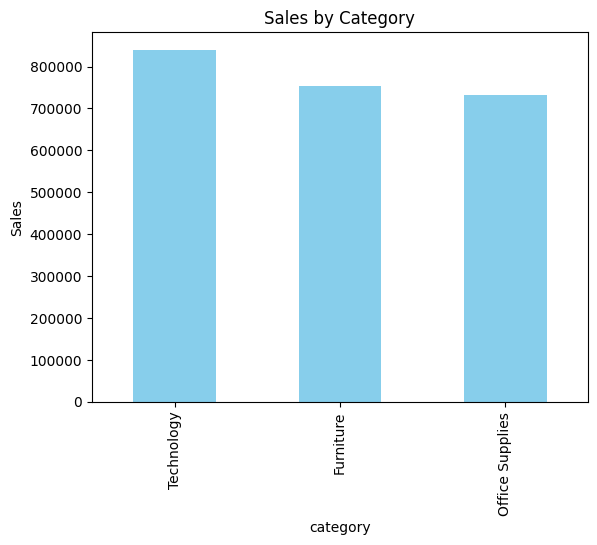

In [33]:
sales_by_category.plot(kind="bar", color="skyblue")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.savefig("../Visuals/sales_by_category.png")
plt.show()

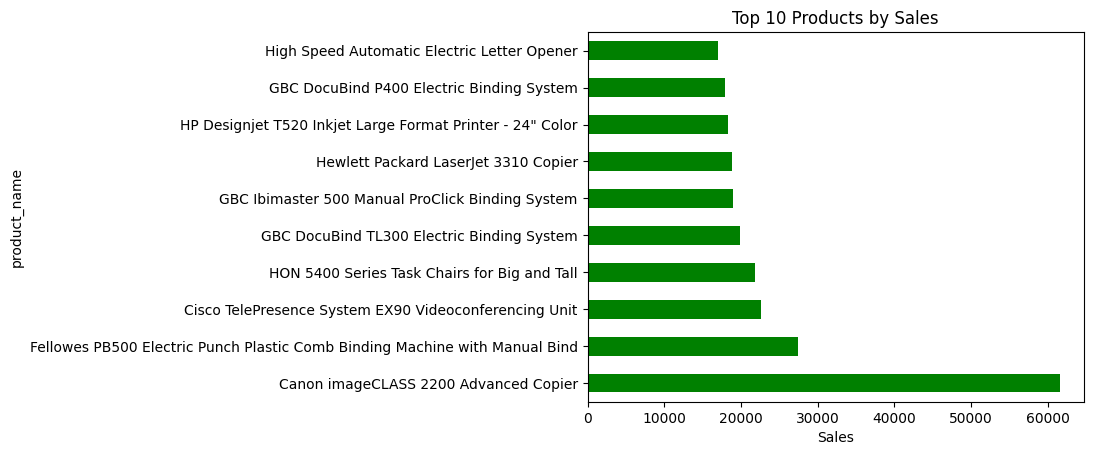

In [35]:
top_products.plot(kind="barh", color="green")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.show()

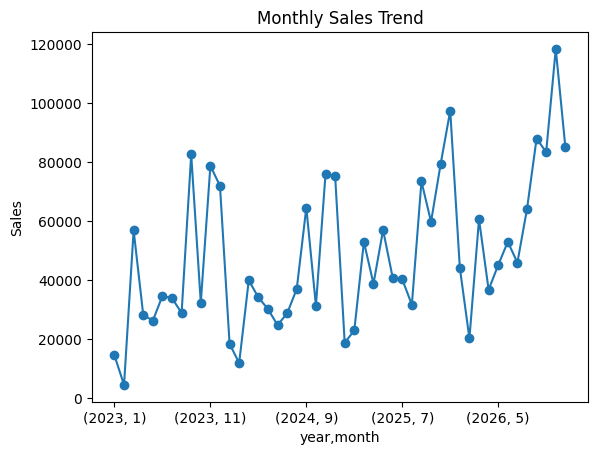

In [34]:
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.savefig("../Visuals/monthly_sales.png")
plt.show()